In [47]:
import json
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from gen_variable_standard_static import \
    metrics_search_for_two_fragments_df
from time import sleep
import pvlib
import pytz
from datetime import date, datetime, timedelta
from datetime import time as py_time

In [2]:
pd.__version__

'2.3.3'

In [3]:
systems_cleaned = pd.read_csv('../../../data/core/systems_cleaned.csv')
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source',
       'num_days_actual_records', 'sample_year'],
      dtype='object')

In [4]:
systems_cleaned.loc[5:10]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
5,34,Andre Agassi Preparatory Academy - Building A,"Las Vegas, NV",America/Los_Angeles,36.1952,-115.1582,620.0,146.64,Bwh,26,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,3626,2011
6,35,Andre Agassi Preparatory Academy - Gymnasium,"Las Vegas, NV",America/Los_Angeles,36.1952,-115.1582,620.0,121.68,Bwh,26,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,3625,2011
7,36,NREL low-X x-Si -1,"Golden, CO",7,39.7040,-105.1773,1794.7,2.21,BSk,12,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,2516,2013
8,50,NREL x-Si 6,"Golden, CO",7,39.7420,-105.1727,1994.7,6.00,BSk,12,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,8455,1995
9,51,NREL x-Si 7,"Golden, CO",7,39.7416,-105.1734,1994.7,6.00,BSk,12,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,8032,1995
10,1199,Distributed Sun - Hunt Valley,"Cockeysville, MD",America/New_York,39.4856,-76.6636,325.0,52.92,Cfa,34,...,True,True,True,True,True,multi-Si,multicrystalline_Si,PVDAQ General,3706,2011


In [5]:
metrics_dir = Path("../../../data/raw/parquet-metrics/")
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_id_set = set(metrics_df.system_id)

In [6]:
ac_power_metrics = metrics_search_for_two_fragments_df(metrics_df, 'ac', 'pow', 'and')
ac_power_systems = set(ac_power_metrics['system_id'])
two_years_days = 2 * 365
enough_data_systems = systems_cleaned[systems_cleaned['num_days_actual_records'] >= two_years_days]
enough_data_ids = set(enough_data_systems.system_id)
enough_data_parquet_power_systems = enough_data_ids.intersection(ac_power_systems)
enough_data_parquet_power_list = list(enough_data_parquet_power_systems)
enough_data_parquet_power_list.sort()

In [7]:
systems_cleaned_enough_ac_data = systems_cleaned[systems_cleaned['system_id'].isin(enough_data_parquet_power_systems)]

In [8]:
systems_cleaned_enough_ac_data.head()

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
2,4,NREL x-Si -1,"Golden, CO",7,39.7406,-105.1774,1795.3,1.00,BSk,12,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,5063,2008
3,10,NREL CIS -1,"Golden, CO",7,39.7404,-105.1774,1792.8,1.12,BSk,12,...,True,True,True,True,True,cis family thin-film,thin_film,PVDAQ General,5893,2007
4,33,Silicor Materials,"Golden, CO",7,39.7404,-105.1772,1794.0,2.40,BSk,12,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,4438,2011
5,34,Andre Agassi Preparatory Academy - Building A,"Las Vegas, NV",America/Los_Angeles,36.1952,-115.1582,620.0,146.64,Bwh,26,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,3626,2011
6,35,Andre Agassi Preparatory Academy - Gymnasium,"Las Vegas, NV",America/Los_Angeles,36.1952,-115.1582,620.0,121.68,Bwh,26,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,3625,2011


In [9]:
enough_data_locs = systems_cleaned_enough_ac_data[['latitude', 'longitude']].drop_duplicates()

In [10]:
practice_loc = (systems_cleaned_enough_ac_data.at[2, 'latitude'], systems_cleaned_enough_ac_data.at[2, 'longitude'])

In [11]:
nsrdb_api = input('What is your NSRDB API key?')

In [12]:
my_email = input('What is your e-mail address?')

In [13]:
my_system_4_year_2007_weather, my_syster_4_year_2007_weather_meta = pvlib.iotools.get_nsrdb_psm4_aggregated(
    latitude=practice_loc[0],
    longitude=practice_loc[1],
    api_key=nsrdb_api,
    email = my_email,
    year=2007,
    time_step=60,
    parameters=['clearsky_dhi', 'clearsky_dni', 'clearsky_ghi', 'dhi', 'dni', 'ghi',
                'solar_zenith_angle'],
    leap_day=True
)

In [14]:
my_syster_4_year_2007_weather_meta

{'Source': 'NSRDB',
 'Location ID': '479494',
 'City': '-',
 'State': '-',
 'Country': '-',
 'Time Zone': -7,
 'Local Time Zone': -7,
 'Clearsky DHI Units': 'w/m2',
 'Clearsky DNI Units': 'w/m2',
 'Clearsky GHI Units': 'w/m2',
 'Dew Point Units': 'c',
 'DHI Units': 'w/m2',
 'DNI Units': 'w/m2',
 'GHI Units': 'w/m2',
 'Solar Zenith Angle Units': 'Degree',
 'Temperature Units': 'c',
 'Pressure Units': 'mbar',
 'Relative Humidity Units': '%',
 'Precipitable Water Units': 'cm',
 'Wind Direction Units': 'Degrees',
 'Wind Speed Units': 'm/s',
 'Cloud Type -15': 'N/A',
 'Cloud Type 0': 'Clear',
 'Cloud Type 1': 'Probably Clear',
 'Cloud Type 2': 'Fog',
 'Cloud Type 3': 'Water',
 'Cloud Type 4': 'Super-Cooled Water',
 'Cloud Type 5': 'Mixed',
 'Cloud Type 6': 'Opaque Ice',
 'Cloud Type 7': 'Cirrus',
 'Cloud Type 8': 'Overlapping',
 'Cloud Type 9': 'Overshooting',
 'Cloud Type 10': 'Unknown',
 'Cloud Type 11': 'Dust',
 'Cloud Type 12': 'Smoke',
 'Fill Flag 0': 'N/A',
 'Fill Flag 1': 'Missing Im

In [15]:
my_system_4_year_2007_weather.head()

,Year,Month,Day,Hour,Minute,dhi_clear,dni_clear,ghi_clear,dhi,dni,ghi,solar_zenith
2007-01-01 00:30:00-07:00,2007,1,1,0,30,0.0,0.0,0.0,0.0,0.0,0.0,162.42
2007-01-01 01:30:00-07:00,2007,1,1,1,30,0.0,0.0,0.0,0.0,0.0,0.0,155.32
2007-01-01 02:30:00-07:00,2007,1,1,2,30,0.0,0.0,0.0,0.0,0.0,0.0,145.00
2007-01-01 03:30:00-07:00,2007,1,1,3,30,0.0,0.0,0.0,0.0,0.0,0.0,133.70
2007-01-01 04:30:00-07:00,2007,1,1,4,30,0.0,0.0,0.0,0.0,0.0,0.0,122.18


In [16]:
my_system_4_year_2007_weather[my_system_4_year_2007_weather['Month']==5]

,Year,Month,Day,Hour,Minute,dhi_clear,dni_clear,ghi_clear,dhi,dni,ghi,solar_zenith
2007-05-01 00:30:00-07:00,2007,5,1,0,30,0.0,0.0,0.0,0.0,0.0,0.0,124.77
2007-05-01 01:30:00-07:00,2007,5,1,1,30,0.0,0.0,0.0,0.0,0.0,0.0,121.21
2007-05-01 02:30:00-07:00,2007,5,1,2,30,0.0,0.0,0.0,0.0,0.0,0.0,114.80
2007-05-01 03:30:00-07:00,2007,5,1,3,30,0.0,0.0,0.0,0.0,0.0,0.0,106.32
2007-05-01 04:30:00-07:00,2007,5,1,4,30,0.0,0.0,0.0,0.0,0.0,0.0,96.43
...,...,...,...,...,...,...,...,...,...,...,...,...
2007-05-31 19:30:00-07:00,2007,5,31,19,30,0.0,0.0,0.0,0.0,0.0,0.0,92.19
2007-05-31 20:30:00-07:00,2007,5,31,20,30,0.0,0.0,0.0,0.0,0.0,0.0,101.46
2007-05-31 21:30:00-07:00,2007,5,31,21,30,0.0,0.0,0.0,0.0,0.0,0.0,109.22
2007-05-31 22:30:00-07:00,2007,5,31,22,30,0.0,0.0,0.0,0.0,0.0,0.0,114.91


In [17]:
my_system_4_year_2007_weather.dtypes

Year              int64
Month             int64
Day               int64
Hour              int64
Minute            int64
dhi_clear       float64
dni_clear       float64
ghi_clear       float64
dhi             float64
dni             float64
ghi             float64
solar_zenith    float64
dtype: object

In [18]:
my_system_4_reset_index = my_system_4_year_2007_weather.reset_index()

In [19]:
my_system_4_reset_index['index'].dtype

datetime64[ns, Etc/GMT+7]

In [20]:
my_system_4_reset_index['time_pandas'] = pd.to_datetime(my_system_4_reset_index['index'])

In [21]:
my_system_4_reset_index.head()

,index,Year,Month,Day,Hour,Minute,dhi_clear,dni_clear,ghi_clear,dhi,dni,ghi,solar_zenith,time_pandas
0,2007-01-01 00:30:00-07:00,2007,1,1,0,30,0.0,0.0,0.0,0.0,0.0,0.0,162.42,2007-01-01 00:30:00-07:00
1,2007-01-01 01:30:00-07:00,2007,1,1,1,30,0.0,0.0,0.0,0.0,0.0,0.0,155.32,2007-01-01 01:30:00-07:00
2,2007-01-01 02:30:00-07:00,2007,1,1,2,30,0.0,0.0,0.0,0.0,0.0,0.0,145.00,2007-01-01 02:30:00-07:00
3,2007-01-01 03:30:00-07:00,2007,1,1,3,30,0.0,0.0,0.0,0.0,0.0,0.0,133.70,2007-01-01 03:30:00-07:00
4,2007-01-01 04:30:00-07:00,2007,1,1,4,30,0.0,0.0,0.0,0.0,0.0,0.0,122.18,2007-01-01 04:30:00-07:00


In [22]:
my_system_4_reset_index[
    (my_system_4_reset_index['Month'] == 3)
    & (my_system_4_reset_index['Day'] == 11)]

,index,Year,Month,Day,Hour,Minute,dhi_clear,dni_clear,ghi_clear,dhi,dni,ghi,solar_zenith,time_pandas
1656,2007-03-11 00:30:00-07:00,2007,3,11,0,30,0.0,0.0,0.0,0.0,0.0,0.0,143.84,2007-03-11 00:30:00-07:00
1657,2007-03-11 01:30:00-07:00,2007,3,11,1,30,0.0,0.0,0.0,0.0,0.0,0.0,139.87,2007-03-11 01:30:00-07:00
1658,2007-03-11 02:30:00-07:00,2007,3,11,2,30,0.0,0.0,0.0,0.0,0.0,0.0,132.26,2007-03-11 02:30:00-07:00
1659,2007-03-11 03:30:00-07:00,2007,3,11,3,30,0.0,0.0,0.0,0.0,0.0,0.0,122.52,2007-03-11 03:30:00-07:00
1660,2007-03-11 04:30:00-07:00,2007,3,11,4,30,0.0,0.0,0.0,0.0,0.0,0.0,111.64,2007-03-11 04:30:00-07:00
1661,2007-03-11 05:30:00-07:00,2007,3,11,5,30,0.0,0.0,0.0,0.0,0.0,0.0,100.24,2007-03-11 05:30:00-07:00
1662,2007-03-11 06:30:00-07:00,2007,3,11,6,30,13.0,253.0,20.0,13.0,253.0,20.0,88.43,2007-03-11 06:30:00-07:00
1663,2007-03-11 07:30:00-07:00,2007,3,11,7,30,41.0,745.0,204.0,41.0,745.0,204.0,77.32,2007-03-11 07:30:00-07:00
1664,2007-03-11 08:30:00-07:00,2007,3,11,8,30,53.0,907.0,414.0,53.0,907.0,414.0,66.59,2007-03-11 08:30:00-07:00
1665,2007-03-11 09:30:00-07:00,2007,3,11,9,30,60.0,993.0,602.0,60.0,993.0,602.0,56.94,2007-03-11 09:30:00-07:00


### OK, let us practice System 34 (named timezone vs. UTC timezone)

In [23]:
system_id = 34
my_year = 2011
my_basic_dir = '../../../../data_ds_project/testing_yearly_parquet/'
my_direct_dir = Path(my_basic_dir + f'{system_id}/')
my_year_pq = pq.ParquetDataset(
    my_direct_dir,
    filters=[('year', '==', my_year)],
)
my_year_df = my_year_pq.read().to_pandas()


In [24]:
system_34_rows = systems_cleaned_enough_ac_data[systems_cleaned_enough_ac_data['system_id'] == 34]
system_34_rows

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
5,34,Andre Agassi Preparatory Academy - Building A,"Las Vegas, NV",America/Los_Angeles,36.1952,-115.1582,620.0,146.64,Bwh,26,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,3626,2011


In [25]:
my_year_df['time'].dtype

dtype('<M8[ns]')

Check my system

In [26]:
np.dtype('datetime64[ns]') == np.dtype('<M8[ns]')

True

As per <https://stackoverflow.com/questions/29206612/difference-between-data-type-datetime64ns-and-m8ns>, M8[ns] with a less-than/greater-than symbol are subclasses of datetime64[ns] (almost implementations) with a particular little-endian/big-endian structure.

In [27]:
my_year_df.head()

,time,ac_power_kW,year
0,2011-01-01 00:00:00,-0.2,2011
1,2011-01-01 00:15:00,-0.3,2011
2,2011-01-01 00:30:00,-0.3,2011
3,2011-01-01 00:45:00,-0.2,2011
4,2011-01-01 01:00:00,-0.3,2011


In [28]:
mar_11_data = my_year_df[my_year_df['time'].dt.date==date(2011, 3, 13)]

In [29]:
mar_11_data.iloc[40:60]

,time,ac_power_kW,year
6838,2011-03-13 10:00:00,93.2,2011
6839,2011-03-13 10:15:00,95.8,2011
6840,2011-03-13 10:30:00,98.8,2011
6841,2011-03-13 10:45:00,97.4,2011
6842,2011-03-13 11:00:00,93.1,2011
6843,2011-03-13 11:15:00,87.4,2011
6844,2011-03-13 11:30:00,94.7,2011
6845,2011-03-13 11:45:00,85.7,2011
6846,2011-03-13 12:00:00,101.2,2011
6847,2011-03-13 12:15:00,93.9,2011


In [30]:
nov_6_data = my_year_df[my_year_df['time'].dt.date==date(2011, 11, 6)]

In [31]:
nov_6_data.iloc[4:16]

,time,ac_power_kW,year
29645,2011-11-06 01:00:00,-0.3,2011
29646,2011-11-06 01:15:00,-0.3,2011
29647,2011-11-06 01:30:00,-0.2,2011
29648,2011-11-06 01:45:00,-0.3,2011
29649,2011-11-06 02:00:00,-0.3,2011
29650,2011-11-06 02:15:00,-0.2,2011
29651,2011-11-06 02:30:00,-0.2,2011
29652,2011-11-06 02:45:00,-0.2,2011
29653,2011-11-06 03:00:00,-0.3,2011
29654,2011-11-06 03:15:00,-0.3,2011


In [32]:
my_year_df['time_better'] = my_year_df['time'].dt.tz_localize(system_34_rows.at[5, 'timezone_or_utc_offset'])

NonExistentTimeError: 2011-03-13 02:00:00

In [11]:
my_timezones = set(systems_cleaned_enough_ac_data['timezone_or_utc_offset'].unique())
my_timezones

{'5',
 '7',
 'America/Chicago',
 'America/Denver',
 'America/Los_Angeles',
 'America/New_York'}

In [12]:
systems_cleaned_enough_ac_data[systems_cleaned_enough_ac_data['timezone_or_utc_offset'] == '5'].system_id

156    4901
157    4901
158    4902
159    4903
Name: system_id, dtype: int64

In [13]:
systems_cleaned_enough_ac_data[systems_cleaned_enough_ac_data['timezone_or_utc_offset'] == '7'].system_id

2         4
3        10
4        33
7        36
8        50
9        51
17     1208
68     1283
69     1284
70     1289
107    1332
108    1332
Name: system_id, dtype: int64

In [14]:
timezone_sample_systems = {
    time_zone: (0, 0) for time_zone in my_timezones
}
for time_zone in my_timezones:
    systems_this_timezone = systems_cleaned_enough_ac_data[systems_cleaned_enough_ac_data['timezone_or_utc_offset'] == time_zone]
    first_ind = systems_this_timezone.index[0]
    timezone_sample_systems[time_zone] = (int(first_ind), int(systems_cleaned_enough_ac_data.at[first_ind, 'system_id']))

In [15]:
timezone_sample_systems

{'5': (156, 4901),
 'America/Chicago': (35, 1244),
 'America/Los_Angeles': (5, 34),
 'America/New_York': (10, 1199),
 '7': (2, 4),
 'America/Denver': (150, 1430)}

In [16]:
before_after_dst = {
    'America/Los_Angeles': (8, 7),
    'America/Denver': (7, 6),
    'America/Chicago': (6, 5),
    'America/New_York': (5, 4)
}

In [17]:
def is_good_timezone(
    input_dir: str,
    system_id: int,
    systems_cleaned: pd.DataFrame,
    before_after_dst: dict,
    print_messages: bool = True
):
    relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
    first_ind = relevant_rows_systems.index[0]
    sample_year = int(systems_cleaned.at[first_ind, 'sample_year'])
    nominal_timezone = systems_cleaned.at[first_ind, 'timezone_or_utc_offset']
    if len(nominal_timezone) == 1:  #single-digit
        nominal_timezone = f'Etc/GMT+{nominal_timezone}'

    # grab data from sample year
    core_dir = Path(input_dir + f'{system_id}/')
    sample_year_pq = pq.ParquetDataset(
        core_dir,
        filters = [('year', '==', sample_year)]
    )
    sample_year_df = sample_year_pq.read().to_pandas()
    try:
        sample_year_df['time'] = sample_year_df['time'].dt.tz_localize(nominal_timezone)
        if print_messages:
            print(f'System {system_id} has a nice timezone of {nominal_timezone}.')
        return True
    except (pytz.NonExistentTimeError, pytz.AmbiguousTimeError):
        options_tuple = before_after_dst[nominal_timezone]
        if print_messages:
            print(f'System {system_id} between the options in GMT+{options_tuple}')
        return False
    except BaseException as e:
        raise e


In [40]:
for key in timezone_sample_systems.keys():
    (ind, system_id) = timezone_sample_systems[key]
    is_good_timezone(
        '../../../../data_ds_project/testing_yearly_parquet/',
        system_id,
        systems_cleaned,
        before_after_dst
    )  

System 4901 has a nice timezone of Etc/GMT+5.
System 4 has a nice timezone of Etc/GMT+7.
System 1199 has a nice timezone of America/New_York.
System 1430 between the options in GMT+(7, 6)
System 34 between the options in GMT+(8, 7)
System 1244 between the options in GMT+(6, 5)


In [41]:
for system_id in enough_data_parquet_power_list:
    is_good_timezone(
        '../../../../data_ds_project/testing_yearly_parquet/',
        system_id,
        systems_cleaned,
        before_after_dst
    )

System 4 has a nice timezone of Etc/GMT+7.
System 10 has a nice timezone of Etc/GMT+7.
System 33 has a nice timezone of Etc/GMT+7.
System 34 between the options in GMT+(8, 7)
System 35 between the options in GMT+(8, 7)
System 36 has a nice timezone of Etc/GMT+7.
System 50 has a nice timezone of Etc/GMT+7.
System 51 has a nice timezone of Etc/GMT+7.
System 1199 has a nice timezone of America/New_York.
System 1200 has a nice timezone of America/New_York.
System 1201 between the options in GMT+(5, 4)
System 1202 between the options in GMT+(5, 4)
System 1203 between the options in GMT+(5, 4)
System 1204 has a nice timezone of America/New_York.
System 1208 has a nice timezone of Etc/GMT+7.
System 1214 between the options in GMT+(5, 4)
System 1217 between the options in GMT+(5, 4)
System 1219 between the options in GMT+(5, 4)
System 1221 between the options in GMT+(5, 4)
System 1223 between the options in GMT+(5, 4)
System 1225 between the options in GMT+(5, 4)
System 1231 between the option

In [18]:
def is_good_timezone_every_year(
    input_dir: str,
    system_id: int,
    systems_cleaned: pd.DataFrame,
    before_after_dst: dict,
    print_messages: bool = True
):
    relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
    first_ind = relevant_rows_systems.index[0]
    nominal_timezone = systems_cleaned.at[first_ind, 'timezone_or_utc_offset']
    if len(nominal_timezone) == 1:  #single-digit
        nominal_timezone = f'Etc/GMT+{nominal_timezone}'

    
    start_year = 1998
    end_year = 2023
    num_years = end_year - start_year + 1
    # make output range
    data_per_year = pd.DataFrame(
        data = np.full((num_years, 3), pd.NA),
        index = range(start_year, end_year + 1),
        columns= ['good_timezone', 'start_date', 'end_date']
    ) 
    # grab data from sample year
    core_dir = Path(input_dir + f'{system_id}/')  
    for year in range(start_year, end_year + 1):
        current_year_pq = pq.ParquetDataset(
            core_dir,
            filters = [('year', '==', year)]
        )
        current_year_df = current_year_pq.read().to_pandas()
        if current_year_df.shape[0] > 10:
            current_year_df.loc[:, 'date'] = current_year_df['time'].dt.date
            data_per_year.at[year, 'start_date'] = current_year_df['date'].min()
            data_per_year.at[year, 'end_date'] = current_year_df['date'].max()
            # no way of checking if the time too short
            if (
                (data_per_year.at[year, 'end_date'] - data_per_year.at[year, 'start_date'])
                > timedelta(days=30)
            ):
                try:
                    current_year_df['time'] = current_year_df['time'].dt.tz_localize(nominal_timezone)
                    if print_messages:
                        print(f'System {system_id} has a nice timezone of {nominal_timezone} '
                              + f'in the year {year}.')
                    data_per_year.at[year, 'good_timezone'] = True
                except (pytz.NonExistentTimeError, pytz.AmbiguousTimeError):
                    options_tuple = before_after_dst[nominal_timezone]
                    if print_messages:
                        print(f'System {system_id}, year {year}, lies between the options in GMT+{options_tuple}')
                    data_per_year.at[year, 'good_timezone'] = False
                except BaseException as e:
                    raise e
    # drop empty rows
    data_per_year = data_per_year.dropna(axis=0, how='all')
    return data_per_year


In [43]:
is_good_timezone_every_year(
    '../../../../data_ds_project/testing_yearly_parquet/',
    1200,
    systems_cleaned,
    before_after_dst,
    True
)

System 1200 has a nice timezone of America/New_York in the year 2010.
System 1200 has a nice timezone of America/New_York in the year 2011.
System 1200 has a nice timezone of America/New_York in the year 2012.
System 1200 has a nice timezone of America/New_York in the year 2013.
System 1200, year 2014, lies between the options in GMT+(5, 4)
System 1200, year 2015, lies between the options in GMT+(5, 4)
System 1200, year 2016, lies between the options in GMT+(5, 4)
System 1200, year 2017, lies between the options in GMT+(5, 4)
System 1200, year 2018, lies between the options in GMT+(5, 4)
System 1200, year 2019, lies between the options in GMT+(5, 4)
System 1200 has a nice timezone of America/New_York in the year 2020.


,good_timezone,start_date,end_date
2010,True,2010-10-03,2010-12-31
2011,True,2011-01-01,2011-12-31
2012,True,2012-01-01,2012-12-13
2013,True,2013-01-20,2013-12-31
2014,False,2014-01-01,2014-12-31
2015,False,2015-01-01,2015-12-31
2016,False,2016-01-01,2016-12-31
2017,False,2017-01-01,2017-12-31
2018,False,2018-01-01,2018-12-31
2019,False,2019-01-01,2019-12-31


In [19]:
systems_with_some_bad_timestamps = []
systems_with_all_good_timestamps = []
for system_id in enough_data_parquet_power_list:
    timezones_per_year = is_good_timezone_every_year(
        '../../../../data_ds_project/testing_yearly_parquet/',
        system_id,
        systems_cleaned,
        before_after_dst,
        False
    )
    bad_timezones_per_year = timezones_per_year[timezones_per_year['good_timezone'] == False]
    if bad_timezones_per_year.shape[0] > 0:
        systems_with_some_bad_timestamps.append(system_id)
        print(f'System {system_id}')
        print('Bad years:')
        print(timezones_per_year)
        print('')
    else:
        systems_with_all_good_timestamps.append(system_id)
        print(f'System {system_id} has good data.')
        print('')

System 4 has good data.

System 10 has good data.

System 33 has good data.

System 34
Bad years:
     good_timezone  start_date    end_date
2010          True  2010-08-23  2010-12-31
2011         False  2011-01-01  2011-12-31
2012         False  2012-01-01  2012-12-31
2013         False  2013-01-01  2013-12-31
2014         False  2014-01-01  2014-12-31
2015         False  2015-01-01  2015-12-31
2016         False  2016-01-01  2016-12-31
2017         False  2017-01-01  2017-12-31
2018         False  2018-01-01  2018-12-31
2019         False  2019-01-01  2019-12-31
2020          True  2020-01-01  2020-07-26

System 35
Bad years:
     good_timezone  start_date    end_date
2010         False  2010-08-23  2010-12-31
2011         False  2011-01-01  2011-12-31
2012         False  2012-01-01  2012-12-31
2013         False  2013-01-01  2013-12-31
2014         False  2014-01-01  2014-12-31
2015         False  2015-01-01  2015-12-31
2016         False  2016-01-01  2016-12-31
2017         False  

Note, however, that rare "True" years could be caused by a system-down issue at the appropriate timestep.  So need more data to conclude that it is really OK.

In [45]:
systems_with_all_good_timestamps

[4,
 10,
 33,
 36,
 50,
 51,
 1199,
 1204,
 1208,
 1283,
 1284,
 1289,
 1300,
 1307,
 1308,
 1310,
 1332,
 1367,
 4901,
 4902,
 4903]

In [46]:
len(systems_with_some_bad_timestamps)

61

In [20]:
practice_tz = pytz.timezone('America/New_York')
practice_tz._utc_transition_times

[datetime.datetime(1, 1, 1, 0, 0),
 datetime.datetime(1901, 12, 13, 20, 45, 52),
 datetime.datetime(1918, 3, 31, 7, 0),
 datetime.datetime(1918, 10, 27, 6, 0),
 datetime.datetime(1919, 3, 30, 7, 0),
 datetime.datetime(1919, 10, 26, 6, 0),
 datetime.datetime(1920, 3, 28, 7, 0),
 datetime.datetime(1920, 10, 31, 6, 0),
 datetime.datetime(1921, 4, 24, 7, 0),
 datetime.datetime(1921, 9, 25, 6, 0),
 datetime.datetime(1922, 4, 30, 7, 0),
 datetime.datetime(1922, 9, 24, 6, 0),
 datetime.datetime(1923, 4, 29, 7, 0),
 datetime.datetime(1923, 9, 30, 6, 0),
 datetime.datetime(1924, 4, 27, 7, 0),
 datetime.datetime(1924, 9, 28, 6, 0),
 datetime.datetime(1925, 4, 26, 7, 0),
 datetime.datetime(1925, 9, 27, 6, 0),
 datetime.datetime(1926, 4, 25, 7, 0),
 datetime.datetime(1926, 9, 26, 6, 0),
 datetime.datetime(1927, 4, 24, 7, 0),
 datetime.datetime(1927, 9, 25, 6, 0),
 datetime.datetime(1928, 4, 29, 7, 0),
 datetime.datetime(1928, 9, 30, 6, 0),
 datetime.datetime(1929, 4, 28, 7, 0),
 datetime.datetime(

In [21]:
transfer_days = [
    my_datetime.date() for my_datetime in practice_tz._utc_transition_times
]

In [49]:
transfer_days

[datetime.date(1, 1, 1),
 datetime.date(1901, 12, 13),
 datetime.date(1918, 3, 31),
 datetime.date(1918, 10, 27),
 datetime.date(1919, 3, 30),
 datetime.date(1919, 10, 26),
 datetime.date(1920, 3, 28),
 datetime.date(1920, 10, 31),
 datetime.date(1921, 4, 24),
 datetime.date(1921, 9, 25),
 datetime.date(1922, 4, 30),
 datetime.date(1922, 9, 24),
 datetime.date(1923, 4, 29),
 datetime.date(1923, 9, 30),
 datetime.date(1924, 4, 27),
 datetime.date(1924, 9, 28),
 datetime.date(1925, 4, 26),
 datetime.date(1925, 9, 27),
 datetime.date(1926, 4, 25),
 datetime.date(1926, 9, 26),
 datetime.date(1927, 4, 24),
 datetime.date(1927, 9, 25),
 datetime.date(1928, 4, 29),
 datetime.date(1928, 9, 30),
 datetime.date(1929, 4, 28),
 datetime.date(1929, 9, 29),
 datetime.date(1930, 4, 27),
 datetime.date(1930, 9, 28),
 datetime.date(1931, 4, 26),
 datetime.date(1931, 9, 27),
 datetime.date(1932, 4, 24),
 datetime.date(1932, 9, 25),
 datetime.date(1933, 4, 30),
 datetime.date(1933, 9, 24),
 datetime.date

Okay, so *most* systems have some bad timestamps!

In [22]:
def has_dst_change_days_data(
    input_dir: str,
    system_id: int,
    systems_cleaned: pd.DataFrame,
):
    relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
    first_ind = relevant_rows_systems.index[0]
    nominal_timezone = systems_cleaned.at[first_ind, 'timezone_or_utc_offset']
    if len(nominal_timezone) == 1:  #single-digit
        # doesn't have the things I want, but all such systems good anyways!
        return None
    timezone_obj = pytz.timezone(nominal_timezone)
    dst_change_times = timezone_obj._utc_transition_times
    
    start_year = 1998
    end_year = 2023
    num_years = end_year - start_year + 1
    # make output range
    data_per_year = pd.DataFrame(
        data = np.full((num_years, 2), pd.NA),
        index = range(start_year, end_year + 1),
        columns= ['has_start_dst_data', 'has_end_dst_data']
    ) 
    # grab data from sample year
    core_dir = Path(input_dir + f'{system_id}/')  
    for year in range(start_year, end_year + 1):
        current_year_pq = pq.ParquetDataset(
            core_dir,
            filters = [('year', '==', year)]
        )
        current_year_df = current_year_pq.read().to_pandas()
        if current_year_df.shape[0] > 10:
            current_year_df.loc[:, 'date'] = current_year_df['time'].dt.date
            year_transition_dates = [
                my_term.date() for my_term in dst_change_times
                if ((my_term >= datetime(year, 1, 1))
                    and (my_term < datetime(year + 1, 1, 1)))
            ]
            spring_transition_date = year_transition_dates[0]
            fall_transition_date = year_transition_dates[1]
            spring_data = current_year_df[
                current_year_df['date'] == spring_transition_date
            ]
            data_per_year.at[year, 'has_start_dst_data'] = (spring_data.shape[0] > 0)
            fall_data = current_year_df[
                current_year_df['date'] == fall_transition_date
            ]
            data_per_year.at[year, 'has_end_dst_data'] = (fall_data.shape[0] > 0)
    # drop empty rows
    data_per_year = data_per_year.dropna(axis=0, how='all')
    return data_per_year


In [23]:
for system_id in enough_data_parquet_power_list:
    print(f'System {system_id}')
    days_checker = has_dst_change_days_data(
        '../../../../data_ds_project/testing_yearly_parquet/',
        system_id,
        systems_cleaned
    )
    if days_checker is not None:
        print(days_checker)
    else:
        print('No-DST-timezone, all good.')
    print('')

System 4
No-DST-timezone, all good.

System 10
No-DST-timezone, all good.

System 33
No-DST-timezone, all good.

System 34
     has_start_dst_data has_end_dst_data
2010              False            False
2011               True             True
2012               True             True
2013               True             True
2014               True             True
2015               True             True
2016               True             True
2017               True             True
2018               True             True
2019               True             True
2020               True            False

System 35
     has_start_dst_data has_end_dst_data
2010              False             True
2011               True             True
2012               True             True
2013               True             True
2014               True             True
2015               True             True
2016               True             True
2017               True             True
2018 

In [52]:
for system_id in systems_with_all_good_timestamps:
    print(f'System {system_id}')
    data_one = is_good_timezone_every_year(
        '../../../../data_ds_project/testing_yearly_parquet/',
        system_id,
        systems_cleaned,
        before_after_dst,
        False
    )
    days_checker = has_dst_change_days_data(
        '../../../../data_ds_project/testing_yearly_parquet/',
        system_id,
        systems_cleaned
    )
    if days_checker is not None:
        total_data = pd.merge(data_one, days_checker,
                              how='outer',
                              left_index=True, right_index=True)
        print(total_data)
    else:
        print(data_one)
    print('')

System 4
     good_timezone  start_date    end_date
2007          True  2007-08-26  2007-12-31
2008          True  2008-01-01  2008-12-31
2009          True  2009-01-01  2009-06-03
2010          True  2010-01-22  2010-12-31
2011          True  2011-01-01  2011-12-31
2012          True  2012-01-01  2012-12-31
2013          True  2013-01-01  2013-12-31
2014          True  2014-01-01  2014-12-31
2015          True  2015-01-01  2015-12-31
2016          True  2016-01-01  2016-12-31
2017          True  2017-01-01  2017-12-31
2018          True  2018-01-01  2018-12-14
2019          True  2019-01-29  2019-12-17
2020          True  2020-01-23  2020-12-31
2021          True  2021-01-01  2021-12-31
2022          True  2022-01-01  2022-12-31
2023          True  2023-01-01  2023-02-28

System 10
     good_timezone  start_date    end_date
2000          True  2000-04-23  2000-09-01
2006          True  2006-01-09  2006-12-31
2007          True  2007-01-01  2007-12-31
2008          True  2008-01-01  20

Combine them!

In [53]:
good_dst_systems = systems_cleaned[systems_cleaned['system_id'].isin(systems_with_all_good_timestamps)]
good_dst_systems.iloc[10:20]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
69,1284,NREL CIGS-11,Golden CO,7,39.7405,-105.1774,1793.7,1.200,Dfb,12,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,991,2013
70,1289,NREL CIGS-12,Golden CO,7,39.7405,-105.1774,1793.7,1.820,Dfb,12,...,True,True,True,True,True,cylindrical cigs,thin_film,PVDAQ General,2639,2013
77,1300,[1300] St. Petersburg Parks CDP - Demens Landi...,"St Petersburg, FL",America/New_York,27.7701,-82.6290,5.0,NaN,Cfa,45,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,1401,2014
84,1307,[1307] St. Petersburg Parks CDP - J.W. Cate Re...,"Golden, CO",America/New_York,27.7936,-82.7144,5.0,NaN,BSk,45,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,1319,2014
85,1308,[1308] St. Petersburg Parks CDP - Roberts Park...,"St Petersburg, FL",America/New_York,27.8175,-82.6517,5.0,NaN,Cfa,45,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,1402,2014
87,1310,[1310] St. Petersburg Parks CDP - Wildwood Par...,"Golden, CO",America/New_York,27.7589,-82.6700,5.0,NaN,BSk,45,...,True,True,True,True,True,Unknown,unknown,PVDAQ General,1419,2014
107,1332,NREL Parking Garage,"Golden, CO",7,39.7388,-105.1732,1770.0,1153.488,BSk,12,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,3104,2014
108,1332,NREL Parking Garage,"Golden, CO",7,39.7388,-105.1732,1770.0,1153.488,BSk,12,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,3104,2014
139,1367,[1367] City of Henderson-NV - Aquatic Complex,"Henderson, NV",America/Los_Angeles,36.0330,-114.9516,660.0,277.160,Bwh,26,...,True,False,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,2219,2014
156,4901,NIST_Canopy_1,Gaithersburg MD,5,39.1385,-77.2155,137.0,242.500,Cfa,34,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,1325,2015


In [24]:
def all_timezone_data(
    input_dir: str,
    system_id: int,
    systems_cleaned: pd.DataFrame,
    dst_transition_dates: list,
    before_after_dst: dict,
    print_messages: bool = True
):
    # make DataFrame
    start_year = 1998
    end_year = 2023
    num_years = end_year - start_year + 1
    # make output range
    data_per_year = pd.DataFrame(
        data = np.full((num_years, 5), pd.NA),
        index = range(start_year, end_year + 1),
        columns= ['good_timezone', 'start_date', 'end_date', 'has_start_dst_data', 'has_end_dst_data']
    ) 
    relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
    first_ind = relevant_rows_systems.index[0]
    nominal_timezone = systems_cleaned.at[first_ind, 'timezone_or_utc_offset']
    if len(nominal_timezone) == 1:  #no-DST-timestamp.  
        nominal_timezone = f'Etc/GMT+{nominal_timezone}'
        dst_timezone = False
    else:
        dst_timezone = True
    timezone_obj = pytz.timezone(nominal_timezone)
    if dst_timezone:
        dst_change_times = timezone_obj._utc_transition_times
    # grab data from sample year
    core_dir = Path(input_dir + f'{system_id}/')  
    for year in range(start_year, end_year + 1):
        current_year_pq = pq.ParquetDataset(
            core_dir,
            filters = [('year', '==', year)]
        )
        current_year_df = current_year_pq.read().to_pandas()
        if current_year_df.shape[0] > 10:
            current_year_df.loc[:, 'date'] = current_year_df['time'].dt.date
            data_per_year.at[year, 'start_date'] = current_year_df['date'].min()
            data_per_year.at[year, 'end_date'] = current_year_df['date'].max()
            # grab transition dates
            if dst_timezone:
                year_transition_dates = [
                    my_term.date() for my_term in dst_change_times
                    if ((my_term >= datetime(year, 1, 1))
                        and (my_term < datetime(year + 1, 1, 1)))
                ]
            else: # grab from the alternative list
                year_transition_dates = [
                    my_date for my_date in dst_transition_dates
                    if ((my_date >= date(year, 1, 1))
                        and (my_date < date(year + 1, 1, 1)))
                ]
            spring_transition_date = year_transition_dates[0]
            fall_transition_date = year_transition_dates[1]
            spring_data = current_year_df[
                current_year_df['date'] == spring_transition_date
            ]
            data_per_year.at[year, 'has_start_dst_data'] = (spring_data.shape[0] > 0)
            fall_data = current_year_df[
                current_year_df['date'] == fall_transition_date
            ]
            data_per_year.at[year, 'has_end_dst_data'] = (fall_data.shape[0] > 0)
            # if a dst 
            if dst_timezone:
                try:
                    current_year_df['time'] = current_year_df['time'].dt.tz_localize(nominal_timezone)
                    if print_messages:
                        print(f'System {system_id} has a nice timezone of {nominal_timezone} '
                               + f'in the year {year}.')
                    # generally, a good start if has data on DST day, or all data on one side
                    # of the starting transition
                    good_start = (
                        data_per_year.at[year, 'has_start_dst_data']
                        or (data_per_year.at[year, 'start_date'] > spring_transition_date)
                        or (data_per_year.at[year, 'end_date'] < spring_transition_date)
                    )
                    good_end = (
                        data_per_year.at[year, 'has_end_dst_data']
                        or (data_per_year.at[year, 'end_date'] < fall_transition_date)
                        or (data_per_year.at[year, 'start_date'] > fall_transition_date)
                    )
                    # one exception -- if data *only* during between DST days, no information
                    not_middle_only = (
                        (data_per_year.at[year, 'start_date'] < spring_transition_date)
                        or (data_per_year.at[year, 'end_date'] > fall_transition_date)
                    )
                    if good_start and good_end and not_middle_only:
                        data_per_year.at[year, 'good_timezone'] = True
                except (pytz.NonExistentTimeError, pytz.AmbiguousTimeError):
                    options_tuple = before_after_dst[nominal_timezone]
                    if print_messages:
                        print(f'System {system_id}, year {year}, lies between the options in GMT+{options_tuple}')
                    data_per_year.at[year, 'good_timezone'] = False
                except BaseException as e:
                    raise e
            else:  #nominally test, but impossible to fail!
                try:
                    current_year_df['time'] = current_year_df['time'].dt.tz_localize(nominal_timezone)
                    if print_messages:
                        print(f'System {system_id} has a nice timezone of {nominal_timezone} '
                              + f'in the year {year}.')
                    data_per_year.at[year, 'good_timezone'] = True
                except (pytz.NonExistentTimeError, pytz.AmbiguousTimeError):
                    options_tuple = before_after_dst[nominal_timezone]
                    if print_messages:
                        print(f'System {system_id}, year {year}, lies between the options in GMT+{options_tuple}')
                    data_per_year.at[year, 'good_timezone'] = False
                except BaseException as e:
                    raise e
    # drop empty rows and columns
    data_per_year = data_per_year.dropna(axis=0, how='all')
    return data_per_year

In [25]:
for system_id in enough_data_parquet_power_list:
    print(f'System {system_id}')
    print(all_timezone_data(
        '../../../../data_ds_project/testing_yearly_parquet/',
        system_id,
        systems_cleaned,
        transfer_days,
        before_after_dst,
        False
    ))
    print('')

System 4
     good_timezone  start_date    end_date has_start_dst_data has_end_dst_data
2007          True  2007-08-26  2007-12-31              False             True
2008          True  2008-01-01  2008-12-31               True             True
2009          True  2009-01-01  2009-06-03               True            False
2010          True  2010-01-22  2010-12-31               True             True
2011          True  2011-01-01  2011-12-31               True             True
2012          True  2012-01-01  2012-12-31               True             True
2013          True  2013-01-01  2013-12-31               True             True
2014          True  2014-01-01  2014-12-31               True             True
2015          True  2015-01-01  2015-12-31               True             True
2016          True  2016-01-01  2016-12-31               True             True
2017          True  2017-01-01  2017-12-31               True             True
2018          True  2018-01-01  2018-12-14 

In [26]:
transitions_2000 = [
    my_date for my_date in transfer_days if (
        (my_date >= date(2000, 1, 1) and (my_date < date(2001, 1, 1)))
    )
]

In [28]:
middle_only = []
for system_id in enough_data_parquet_power_list:
    my_data = all_timezone_data(
        '../../../../data_ds_project/testing_yearly_parquet/',
        system_id,
        systems_cleaned,
        transfer_days,
        before_after_dst,
        False
    )
    
    for year in my_data.index:
        year_transition_dates = [
                    my_date for my_date in transfer_days
                    if ((my_date >= date(year, 1, 1))
                        and (my_date < date(year + 1, 1, 1)))
        ]
        spring_transition_date = year_transition_dates[0]
        fall_transition_date = year_transition_dates[1]
        if (
            (my_data.at[year, 'start_date'] > spring_transition_date)
            & (my_data.at[year, 'end_date'] < fall_transition_date)
        ):
            middle_only.append((system_id, year))
middle_only

[(10, 2000), (1367, 2015)]

System 10, year 2000 is in a non-DST timezone.
System 1367, Year 2015 might need to be added to some_nulls!

Under current application, NA systems require further investigation

In [27]:
some_nulls = []
for system_id in enough_data_parquet_power_list:
    my_data = all_timezone_data(
        '../../../../data_ds_project/testing_yearly_parquet/',
        system_id,
        systems_cleaned,
        transfer_days,
        before_after_dst,
        False
    )
    # manually add the weird systems
    my_nulls = my_data[my_data['good_timezone'].isna()]
    if my_nulls.shape[0] > 0:
        print(f'System {system_id}')
        print(my_nulls)
        print('')
        some_nulls.append(system_id)

System 34
     good_timezone  start_date    end_date has_start_dst_data has_end_dst_data
2010          <NA>  2010-08-23  2010-12-31              False            False

System 35
     good_timezone  start_date    end_date has_start_dst_data has_end_dst_data
2020          <NA>  2020-01-14  2020-07-26              False            False

System 1200
     good_timezone  start_date    end_date has_start_dst_data has_end_dst_data
2013          <NA>  2013-01-20  2013-12-31              False             True

System 1277
     good_timezone  start_date    end_date has_start_dst_data has_end_dst_data
2020          <NA>  2020-01-01  2020-07-26              False            False

System 1300
     good_timezone  start_date    end_date has_start_dst_data has_end_dst_data
2013          <NA>  2013-02-14  2013-12-31               True            False
2016          <NA>  2016-01-01  2016-12-31              False             True

System 1307
     good_timezone  start_date    end_date has_start_dst_d

Rough idea:
If "True", can proceed!
If "False, must change to (presumably) GMT + (smaller)
If "N/A", must check manually.

## System 34 is a bad-data system.  Let us see if we can detect the bad data.

In [83]:
systems_cleaned[systems_cleaned['system_id'] == 34]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,num_days_actual_records,sample_year
5,34,Andre Agassi Preparatory Academy - Building A,"Las Vegas, NV",America/Los_Angeles,36.1952,-115.1582,620.0,146.64,Bwh,26,...,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General,3626,2011


In [31]:
system_34_weather_path = Path('../../../../data_ds_project/nsrdb/34/data/')
system_34_year_2011_weather_pq = pq.ParquetDataset(
    system_34_weather_path,
    filters = [('Year', '==', 2011)]
)
system_34_year_2011_weather_df = system_34_year_2011_weather_pq.read().to_pandas()
system_34_year_2020_weather_pq = pq.ParquetDataset(
    system_34_weather_path,
    filters = [('Year', '==', 2020)]
)
system_34_year_2020_weather_df = system_34_year_2011_weather_pq.read().to_pandas()

In [32]:
system_34_data_path = Path('../../../../data_ds_project/testing_yearly_parquet/34/')
system_34_year_2011_data_pq = pq.ParquetDataset(
    system_34_data_path,
    filters = [('year', '==', 2011)]
)
system_34_year_2011_data_df = system_34_year_2011_data_pq.read().to_pandas()
system_34_year_2020_data_pq = pq.ParquetDataset(
    system_34_data_path,
    filters = [('year', '==', 2020)]
)
system_34_year_2020_data_df = system_34_year_2020_data_pq.read().to_pandas()

In [ ]:
summer_day_2011_d = system_34_year_2011_data_df[
    (system_34_year_2011_data_df['time'] >=datetime(2011, 6, 1))
    & (system_34_year_2011_data_df['time'] < datetime(2011, 6, 2))
]
summer_day_2011_w = system_34_year_2011_weather_df[
    (system_34_year_2011_weather_df['Month'] == 6)
    & (system_34_year_2011_weather_df['Day'] == 1)
]

# pretend to fix timezones.

In [ ]:
summer_day_2011_d_adjust_1 = summer_day_2011_d.copy(deep=True)
summer_day_2011_d_adjust_2 = summer_day_2011_d.copy(deep=True)
summer_day_2011_d_adjust_1['time'] = summer_day_2011_d_adjust_1['time'].dt.tz_localize('Etc/GMT+8')
summer_day_2011_d_adjust_2['time'] = summer_day_2011_d_adjust_2['time'].dt.tz_localize('Etc/GMT+7')
summer_day_2011_d_adjust_1.loc[:, 'power_rel'] = summer_day_2011_d_adjust_1['ac_power_kW'] / summer_day_2011_d_adjust_1['ac_power_kW'].max()
summer_day_2011_d_adjust_2.loc[:, 'power_rel'] = summer_day_2011_d_adjust_2['ac_power_kW'] / summer_day_2011_d_adjust_2['ac_power_kW'].max()

In [ ]:
summer_day_2011_w.loc[:, 'dhi_rel'] = summer_day_2011_w['dhi'] / summer_day_2011_w['dhi'].max()

C:\Users\ch83b\AppData\Local\Temp\ipykernel_49308\2985869662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summer_day_2011_w.loc[:, 'dhi_rel'] = summer_day_2011_w['dhi'] / summer_day_2011_w['dhi'].max()


In [ ]:
summer_day_2011_w.iloc[4:10]

,Month,Day,Hour,Minute,dhi_clear,dni_clear,ghi_clear,dhi,dni,ghi,solar_zenith,SSA,Year,dhi_rel
2011-06-01 04:30:00-08:00,6,1,4,30,0.0,0.0,0.0,0.0,0.0,0.0,89.46,0.92,2011,0.000000
2011-06-01 05:30:00-08:00,6,1,5,30,51.0,544.0,157.0,59.0,3.0,60.0,78.71,0.92,2011,0.139810
2011-06-01 06:30:00-08:00,6,1,6,30,78.0,744.0,368.0,196.0,58.0,219.0,67.08,0.93,2011,0.464455
2011-06-01 07:30:00-08:00,6,1,7,30,90.0,857.0,580.0,90.0,857.0,580.0,55.10,0.93,2011,0.213270
2011-06-01 08:30:00-08:00,6,1,8,30,101.0,916.0,771.0,383.0,365.0,650.0,43.02,0.93,2011,0.907583
2011-06-01 09:30:00-08:00,6,1,9,30,116.0,935.0,916.0,292.0,709.0,899.0,31.18,0.93,2011,0.691943


In [ ]:
summer_day_2011_d.iloc[16:24]

,time,ac_power_kW,year
14489,2011-06-01 04:00:00,-0.2,2011
14490,2011-06-01 04:15:00,-0.3,2011
14491,2011-06-01 04:30:00,-0.5,2011
14492,2011-06-01 04:45:00,1.3,2011
14493,2011-06-01 05:00:00,3.7,2011
14494,2011-06-01 05:15:00,9.3,2011
14495,2011-06-01 05:30:00,9.8,2011
14496,2011-06-01 05:45:00,11.2,2011


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

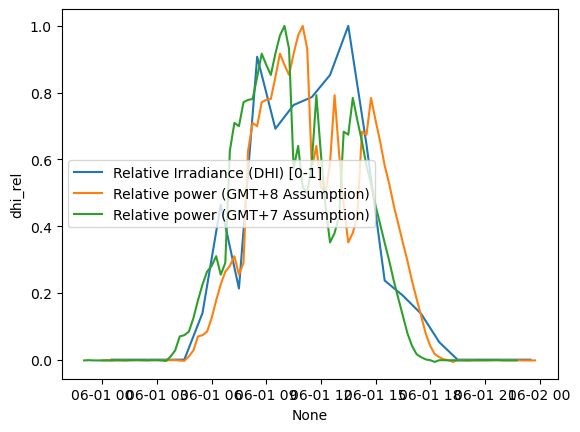

In [ ]:
sns.lineplot(
    x = summer_day_2011_w.index,
    y = summer_day_2011_w.dhi_rel,
    label='Relative Irradiance (DHI) [0-1]'
)
sns.lineplot(
    x = summer_day_2011_d_adjust_1['time'], 
    y = summer_day_2011_d_adjust_1['power_rel'],
    label = 'Relative power (GMT+8 Assumption)'
)
sns.lineplot(
    x = summer_day_2011_d_adjust_2['time'], 
    y = summer_day_2011_d_adjust_2['power_rel'],
    label = 'Relative power (GMT+7 Assumption)'
)
plt.show()

Thus, GMT +8 more likely -- some change in data, somehow?

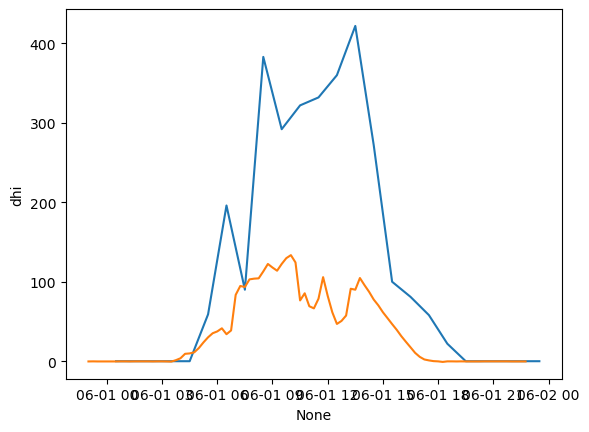

In [ ]:
sns.lineplot(
    x = summer_day_2011_w.index,
    y = summer_day_2011_w.dhi
)
sns.lineplot(
    x = summer_day_2011_d_adjust_2['time'], 
    y = summer_day_2011_d_adjust_2['ac_power_kW']
)
plt.show()

Weird!  Let us try finer time-steps and see if that fixes it!

In [ ]:
system_34_rows = systems_cleaned_enough_ac_data[systems_cleaned_enough_ac_data['system_id'] == 34]
first_ind = system_34_rows.index[0]

In [ ]:
my_system_34_year_2011_weather_finer, my_system_34_year_2011_weather_meta = pvlib.iotools.get_nsrdb_psm4_aggregated(
    latitude=system_34_rows.at[first_ind, 'latitude'],
    longitude=system_34_rows.at[first_ind, 'longitude'],
    api_key=nsrdb_api,
    email = my_email,
    year=2011,
    time_step=30,
    parameters=['clearsky_dhi', 'clearsky_dni', 'clearsky_ghi', 'dhi', 'dni', 'ghi',
                'solar_zenith_angle'],
    leap_day=True
)

In [ ]:
my_system_34_year_2011_weather_finer.head()

,Year,Month,Day,Hour,Minute,dhi_clear,dni_clear,ghi_clear,dhi,dni,ghi,solar_zenith,dhi_rel
2011-01-01 00:00:00-08:00,2011,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,166.36,0.0
2011-01-01 00:30:00-08:00,2011,1,1,0,30,0.0,0.0,0.0,0.0,0.0,0.0,163.46,0.0
2011-01-01 01:00:00-08:00,2011,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,158.92,0.0
2011-01-01 01:30:00-08:00,2011,1,1,1,30,0.0,0.0,0.0,0.0,0.0,0.0,153.57,0.0
2011-01-01 02:00:00-08:00,2011,1,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,147.84,0.0


In [ ]:
my_system_34_year_2011_weather_finer.loc[:, 'dhi_rel'] = my_system_34_year_2011_weather_finer['dhi'] / my_system_34_year_2011_weather_finer['dhi'].max()

In [ ]:
my_system_34_w_better_day = my_system_34_year_2011_weather_finer[
    (my_system_34_year_2011_weather_finer['Month'] == 6)
    & (my_system_34_year_2011_weather_finer['Day'] == 1)
]

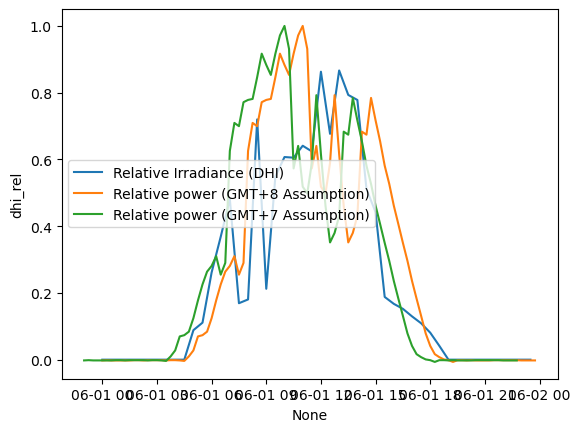

In [ ]:
sns.lineplot(
    x = my_system_34_w_better_day.index,
    y = my_system_34_w_better_day.dhi_rel,
    label='Relative Irradiance (DHI)',
)
sns.lineplot(
    x = summer_day_2011_d_adjust_1['time'], 
    y = summer_day_2011_d_adjust_1['power_rel'],
    label = 'Relative power (GMT+8 Assumption)'
)
sns.lineplot(
    x = summer_day_2011_d_adjust_2['time'], 
    y = summer_day_2011_d_adjust_2['power_rel'],
    label = 'Relative power (GMT+7 Assumption)'
)
plt.show()

GMT+8 does still look like a slightly better fit!

Compare to a winter day (no issue)

In [ ]:
my_system_34_w_better_day_two = my_system_34_year_2011_weather_finer[
    (my_system_34_year_2011_weather_finer['Month'] == 2)
    & (my_system_34_year_2011_weather_finer['Day'] == 1)
]

In [ ]:
my_system_34_w_better_day_two.head()

,Year,Month,Day,Hour,Minute,dhi_clear,dni_clear,ghi_clear,dhi,dni,ghi,solar_zenith,dhi_rel
2011-02-01 00:00:00-08:00,2011,2,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,160.91,0.0
2011-02-01 00:30:00-08:00,2011,2,1,0,30,0.0,0.0,0.0,0.0,0.0,0.0,159.35,0.0
2011-02-01 01:00:00-08:00,2011,2,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,156.00,0.0
2011-02-01 01:30:00-08:00,2011,2,1,1,30,0.0,0.0,0.0,0.0,0.0,0.0,151.48,0.0
2011-02-01 02:00:00-08:00,2011,2,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,146.27,0.0


In [ ]:
winter_day_2011 = system_34_year_2011_data_df[
    (system_34_year_2011_data_df['time'] >=datetime(2011, 2, 1))
    & (system_34_year_2011_data_df['time'] < datetime(2011, 2, 2))
]
winter_day_2011.loc[:, 'power_rel'] = winter_day_2011.loc[:, 'ac_power_kW'] / winter_day_2011['ac_power_kW'].max()

C:\Users\ch83b\AppData\Local\Temp\ipykernel_49308\902388745.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter_day_2011.loc[:, 'power_rel'] = winter_day_2011.loc[:, 'ac_power_kW'] / winter_day_2011['ac_power_kW'].max()


In [ ]:
winter_day_2011.head()

,time,ac_power_kW,year,power_rel
2976,2011-02-01 00:00:00,-0.2,2011,-0.001986
2977,2011-02-01 00:15:00,-0.3,2011,-0.002979
2978,2011-02-01 00:30:00,-0.2,2011,-0.001986
2979,2011-02-01 00:45:00,-0.2,2011,-0.001986
2980,2011-02-01 01:00:00,-0.2,2011,-0.001986


In [ ]:
winter_day_2011_gmt_8 = winter_day_2011.copy(deep=True)
winter_day_2011_gmt_8['time'] = winter_day_2011_gmt_8['time'].dt.tz_localize('Etc/GMT+8')
winter_day_2011_gmt_7 = winter_day_2011.copy(deep=True)
winter_day_2011_gmt_7['time'] = winter_day_2011_gmt_7['time'].dt.tz_localize('Etc/GMT+7')
winter_day_2011_tz_official = winter_day_2011.copy(deep=True)
winter_day_2011_tz_official['time'] = winter_day_2011_tz_official['time'].dt.tz_localize(system_34_rows.at[first_ind, 'timezone_or_utc_offset'])

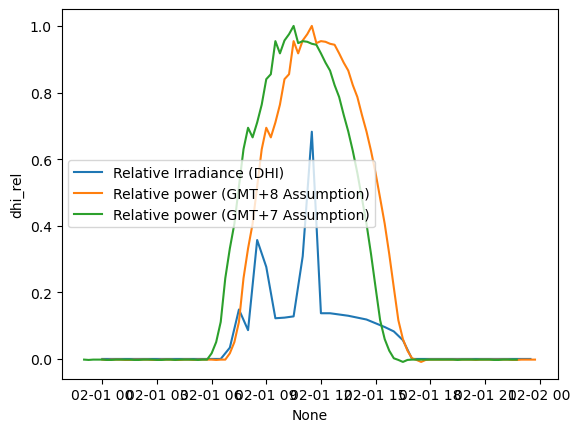

In [ ]:
sns.lineplot(
    x = my_system_34_w_better_day_two.index,
    y = my_system_34_w_better_day_two.dhi_rel,
    label='Relative Irradiance (DHI)'
)
sns.lineplot(
    data = winter_day_2011_gmt_8,
    x = 'time',
    y = 'power_rel',
    label = 'Relative power (GMT+8 Assumption)'
)
sns.lineplot(
    data = winter_day_2011_gmt_7,
    x = 'time',
    y = 'power_rel',
    label = 'Relative power (GMT+7 Assumption)'
)
plt.show()

Looks like it may be GMT+7 throughout (which would be nice!)

Can I just make a time object for consecuitve days and compare them?

In [33]:
change_days_2011 = [
    my_date for my_date in transfer_days
    if (
        (my_date >= date(2011, 1, 1))
        & (my_date < date(2012, 1, 1))
    )
]
change_days_2011

[datetime.date(2011, 3, 13), datetime.date(2011, 11, 6)]

In [34]:
start_day = 10
end_day = 16
power_data_day_range = system_34_year_2011_data_df.loc[
    (system_34_year_2011_data_df['time'] >= datetime(2011, 3, start_day))
    & (system_34_year_2011_data_df['time'] < datetime(2011, 3, end_day+1))
]
power_data_day_range.loc[:, 'date'] = power_data_day_range['time'].dt.date
power_data_day_range.loc[:, 'time_of_day'] = power_data_day_range.apply(
    lambda row: row['time'].time(),
    axis=1
)
power_data_day_range.loc[:, 'offset'] = power_data_day_range.apply(
    lambda row: row['time'] - (row['date'] - date(2011, 3, start_day)),
    axis=1
)



C:\Users\ch83b\AppData\Local\Temp\ipykernel_16424\1669916812.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  power_data_day_range.loc[:, 'date'] = power_data_day_range['time'].dt.date
C:\Users\ch83b\AppData\Local\Temp\ipykernel_16424\1669916812.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  power_data_day_range.loc[:, 'time_of_day'] = power_data_day_range.apply(
C:\Users\ch83b\AppData\Local\Temp\ipykernel_16424\1669916812.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

In [35]:
power_data_power_max = power_data_day_range['ac_power_kW'].max()
threshold = power_data_power_max * 0.01

In [36]:
power_data_large = power_data_day_range[power_data_day_range['ac_power_kW'] >= threshold]

In [ ]:
power_data_large.groupby(['date'])['time_of_day'].min()

date
2011-03-10    06:15:00
2011-03-11    06:15:00
2011-03-12    06:15:00
2011-03-13    06:15:00
2011-03-14    06:30:00
2011-03-15    06:00:00
2011-03-16    06:15:00
Name: time_of_day, dtype: object

In [41]:
power_data_starts = power_data_large.groupby(['date'])['time_of_day'].min()
power_data_starts.max()

datetime.time(6, 30)

In [55]:
def time_to_arithmetizable(time_in: py_time):
    time_h = time_in.hour
    time_m = time_h * 60 + time_in.minute
    time_s = time_m * 60 + time_in.second
    return time_s / 60

In [49]:
power_data_starts_arith = power_data_starts.apply(time_to_arithmetizable)

In [51]:
power_data_starts_arith.value_counts().index[0] - power_data_starts_arith.min()

np.int64(900)

In [44]:
power_data_starts.value_counts().index[0]

datetime.time(6, 15)

In [46]:
power_data_starts.value_counts().index[0] - power_data_starts.min()

TypeError: unsupported operand type(s) for -: 'datetime.time' and 'datetime.time'

Oof -- cannot subtract abstract times (as opposed to datetimes!)

Can count seconds, though.  Say more than 45 minutes off, ever, is a problem.

OK, so clearly no 'jump' in time as written, but given the 15-min. window + natural noise, *cannot* too precisely force the starting 'good' increment to be stable'

Can probably just do +- 15 min. from mode or mean, though?

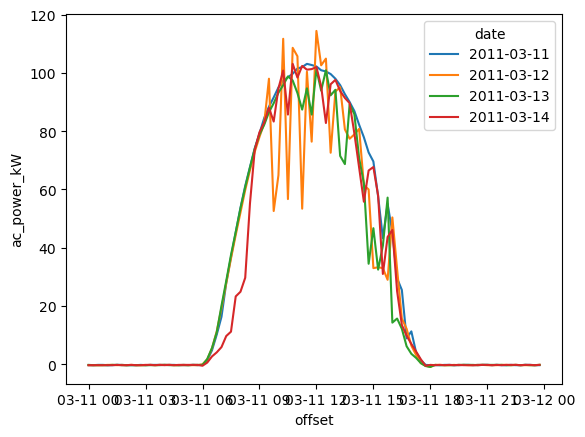

In [ ]:
sns.lineplot(
    data= power_data_day_range,
    x='offset',
    y='ac_power_kW',
    hue='date'
)
plt.show()

In [ ]:
power_data_day_range.time_of_day.value_counts(dropna=False)

time_of_day
00:00:00    4
00:15:00    4
17:30:00    4
17:15:00    4
17:00:00    4
           ..
07:15:00    4
07:00:00    4
06:45:00    4
06:30:00    4
23:45:00    4
Name: count, Length: 96, dtype: int64

In [ ]:
change_days_2020 = [
    my_date for my_date in transfer_days
    if (
        (my_date >= date(2020, 1, 1))
        & (my_date < date(2021, 1, 1))
    )
]
change_days_2020

[datetime.date(2020, 3, 8), datetime.date(2020, 11, 1)]

In [ ]:
start_day = 6
end_day = 9
power_data_day_range = system_34_year_2020_data_df.loc[
    (system_34_year_2020_data_df['time'] >= datetime(2020, 3, start_day))
    & (system_34_year_2020_data_df['time'] < datetime(2020, 3, end_day+1))
]
power_data_day_range.loc[:, 'date'] = power_data_day_range['time'].dt.date
power_data_day_range.loc[:, 'time_of_day'] = power_data_day_range.apply(
    lambda row: row['time'].time(),
    axis=1
)
power_data_day_range.loc[:, 'offset'] = power_data_day_range.apply(
    lambda row: row['time'] - (row['date'] - date(2020, 3, start_day)),
    axis=1
)

C:\Users\ch83b\AppData\Local\Temp\ipykernel_39784\338940952.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  power_data_day_range.loc[:, 'date'] = power_data_day_range['time'].dt.date
C:\Users\ch83b\AppData\Local\Temp\ipykernel_39784\338940952.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  power_data_day_range.loc[:, 'time_of_day'] = power_data_day_range.apply(
C:\Users\ch83b\AppData\Local\Temp\ipykernel_39784\338940952.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [ ]:
power_data_day_range.iloc[20:40]

,time,ac_power_kW,year,date,time_of_day,offset
6249,2020-03-06 05:00:00,-0.2,2020,2020-03-06,05:00:00,2020-03-06 05:00:00
6250,2020-03-06 05:15:00,-0.2,2020,2020-03-06,05:15:00,2020-03-06 05:15:00
6251,2020-03-06 05:30:00,-0.2,2020,2020-03-06,05:30:00,2020-03-06 05:30:00
6252,2020-03-06 05:45:00,-0.2,2020,2020-03-06,05:45:00,2020-03-06 05:45:00
6253,2020-03-06 06:00:00,-0.7,2020,2020-03-06,06:00:00,2020-03-06 06:00:00
6254,2020-03-06 06:15:00,-0.3,2020,2020-03-06,06:15:00,2020-03-06 06:15:00
6255,2020-03-06 06:30:00,1.8,2020,2020-03-06,06:30:00,2020-03-06 06:30:00
6256,2020-03-06 06:45:00,2.5,2020,2020-03-06,06:45:00,2020-03-06 06:45:00
6257,2020-03-06 07:00:00,2.9,2020,2020-03-06,07:00:00,2020-03-06 07:00:00
6258,2020-03-06 07:15:00,4.4,2020,2020-03-06,07:15:00,2020-03-06 07:15:00


In [ ]:
power_data_day_range.iloc[110:130]

,time,ac_power_kW,year,date,time_of_day,offset
6339,2020-03-07 03:30:00,-0.2,2020,2020-03-07,03:30:00,2020-03-06 03:30:00
6340,2020-03-07 03:45:00,-0.2,2020,2020-03-07,03:45:00,2020-03-06 03:45:00
6341,2020-03-07 04:00:00,-0.2,2020,2020-03-07,04:00:00,2020-03-06 04:00:00
6342,2020-03-07 04:15:00,-0.2,2020,2020-03-07,04:15:00,2020-03-06 04:15:00
6343,2020-03-07 04:30:00,-0.3,2020,2020-03-07,04:30:00,2020-03-06 04:30:00
6344,2020-03-07 04:45:00,-0.2,2020,2020-03-07,04:45:00,2020-03-06 04:45:00
6345,2020-03-07 05:00:00,-0.2,2020,2020-03-07,05:00:00,2020-03-06 05:00:00
6346,2020-03-07 05:15:00,-0.2,2020,2020-03-07,05:15:00,2020-03-06 05:15:00
6347,2020-03-07 05:30:00,-0.2,2020,2020-03-07,05:30:00,2020-03-06 05:30:00
6348,2020-03-07 05:45:00,-0.2,2020,2020-03-07,05:45:00,2020-03-06 05:45:00


In [ ]:
power_data_day_range.iloc[210:230]

,time,ac_power_kW,year,date,time_of_day,offset
6439,2020-03-08 05:30:00,-0.2,2020,2020-03-08,05:30:00,2020-03-06 05:30:00
6440,2020-03-08 05:45:00,-0.2,2020,2020-03-08,05:45:00,2020-03-06 05:45:00
6441,2020-03-08 06:00:00,-0.3,2020,2020-03-08,06:00:00,2020-03-06 06:00:00
6442,2020-03-08 06:15:00,-0.2,2020,2020-03-08,06:15:00,2020-03-06 06:15:00
6443,2020-03-08 06:30:00,-0.3,2020,2020-03-08,06:30:00,2020-03-06 06:30:00
6444,2020-03-08 06:45:00,-0.2,2020,2020-03-08,06:45:00,2020-03-06 06:45:00
6445,2020-03-08 07:00:00,-0.7,2020,2020-03-08,07:00:00,2020-03-06 07:00:00
6446,2020-03-08 07:15:00,-0.2,2020,2020-03-08,07:15:00,2020-03-06 07:15:00
6447,2020-03-08 07:30:00,0.5,2020,2020-03-08,07:30:00,2020-03-06 07:30:00
6448,2020-03-08 07:45:00,2.2,2020,2020-03-08,07:45:00,2020-03-06 07:45:00


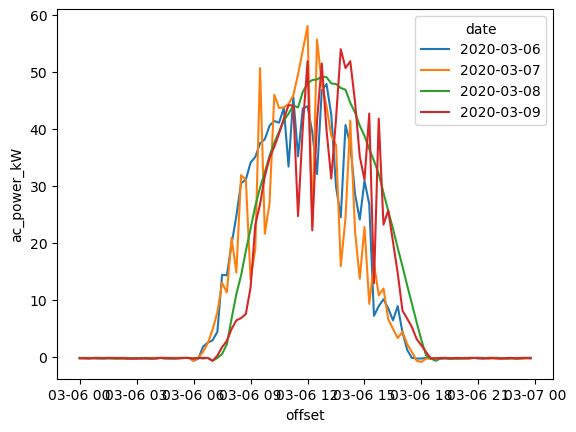

In [ ]:
sns.lineplot(
    data= power_data_day_range,
    x='offset',
    y='ac_power_kW',
    hue='date'
)
plt.show()

march_2011 = 

So 2020 really is a good DST date!  Good!

### Towards timezone verification

#### Step 1: Sanity check

For systems with no datetime timezone, how much does the starting time (measured) vary over a week?

In [53]:
def seasons_classifer(
    spring_dst_date: date,
    fall_dst_date: date,
    data_year_start: date,
    data_year_end: date
):
    seasons_dict = {
        'start_only': (data_year_end < spring_dst_date),
        'spring_transfer': (
            (data_year_start < spring_dst_date)
            and (data_year_end > spring_dst_date)
        ),
        'middle_only': (
            (data_year_start > spring_dst_date)
            and (data_year_end < fall_dst_date)
        ),
        'fall_transfer': (
            (data_year_start < fall_dst_date)
            and (data_year_end > fall_dst_date)
        ),
        'end_only': data_year_end > fall_dst_date,
    }
    return seasons_dict

In [57]:
def data_around_transition(
    input_dir: str,
    system_id: int,
    year: int,
    center_date: date,
    radius: int = 7
):
    # start by going backwards radius days.
    transfer_start = center_date - timedelta(days=radius)
    # convert datetime.date to datetime.datetime
    transfer_start = datetime(
        transfer_start.year,
        transfer_start.month,
        transfer_start.day
    )
    # ditto for upper side
    transfer_end = center_date + timedelta(days=radius)
    transfer_end = datetime(
        transfer_end.year,
        transfer_end.month,
        transfer_end.day
    )
    # load data
    if input_dir[-1] == '/':
        direct_dir = f'{input_dir}{system_id}/'
    else:
        direct_dir = f'{input_dir}/{system_id}/'
    transfer_data_pq = pq.ParquetDataset(
        direct_dir,
        filters = [('year', '==', year),
                   ('time', '>=', transfer_start),
                   ('time', '<=', transfer_end)]
    )
    transfer_data_df = transfer_data_pq.read().to_pandas()
    if transfer_data_df.shape[0] >= 10:
        return transfer_data_df
    else:
        return None

In [64]:
def data_range_local(
    df: pd.DataFrame,
):
    power_columns = [
        col_name for col_name in df.columns
        if 'pow' in col_name
    ]
    lower_spread = 0
    upper_spread = 0
    for pow_name in power_columns:
        local_max = df[pow_name].max()
        threshold = 0.01 * local_max
        df_pow = df[df[pow_name] >= threshold].copy(deep=True)
        df_pow = df_pow[['time', pow_name]]
        df_pow.loc[:, 'date'] = df_pow['time'].dt.date
        df_pow.loc[:, 'time_of_day'] = df_pow['time'].dt.time
        df_pow.loc[:, 'time_of_day_arith'] = df_pow.apply(
            lambda row: time_to_arithmetizable(row['time_of_day']),
            axis=1
        )
        # grab (minutes of) starting and ending times
        df_pow_daily_terms = df_pow.groupby(['date'])['time_of_day_arith'].agg(['min', 'max'])
        start_min = df_pow_daily_terms['min'].min()
        start_mode = df_pow_daily_terms['min'].value_counts().index[0]
        start_max = df_pow_daily_terms['min'].max()
        loc_lower_spread = max(start_max - start_mode, start_mode - start_min)
        lower_spread = max(lower_spread, loc_lower_spread)
        end_min = df_pow_daily_terms['max'].min()
        end_mode = df_pow_daily_terms['max'].value_counts().index[0]
        end_max = df_pow_daily_terms['max'].max()
        loc_upper_spread = max(end_max - end_mode, end_mode - end_min)
        upper_spread = max(upper_spread, loc_upper_spread)
    return (lower_spread, upper_spread)
    


In [60]:
system_34_year_2011_data_df.groupby('year')['ac_power_kW'].agg(['min', 'max'])

C:\Users\ch83b\AppData\Local\Temp\ipykernel_16424\3483229063.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  system_34_year_2011_data_df.groupby('year')['ac_power_kW'].agg(['min', 'max'])


,min,max
year,,
2010,NaN,NaN
2011,-1.3,133.9
2012,NaN,NaN
2013,NaN,NaN
2014,NaN,NaN
2015,NaN,NaN
2016,NaN,NaN
2017,NaN,NaN
2018,NaN,NaN


In [63]:
data_range_local(
    system_34_year_2011_data_df,
    ['ac_power_kW',],
)

(np.float64(420.0), np.float64(375.0))

In [ ]:
def starting_hour_consistency(
    input_dir: str,
    system_id: int,
    systems_cleaned: pd.DataFrame,
    dst_transition_dates: list,
    before_after_dst: dict,
    print_messages: bool = True
):
    total_timezone_data = all_timezone_data(
        input_dir,
        system_id,
        systems_cleaned,
        dst_transition_dates,
        before_after_dst,
        print_messages
    )
    relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
    first_ind = relevant_rows_systems.index[0]
    nominal_timezone = systems_cleaned.at[first_ind, 'timezone_or_utc_offset']
    if len(nominal_timezone) == 1:  #no-DST-timestamp.  
        nominal_timezone = f'Etc/GMT+{nominal_timezone}'
    else:
        # not good for present checking against baseline
        return None
    # make output table
    num_years = len(total_timezone_data.index)
    cols = ['spring_valid', 'fall_valid', 'seconds_spread_down', 'seconds_spread_up']
    bool_data = np.full((num_years, 2), fill_value=False)
    float_data = np.full((num_years, 2), fill_value=np.nan)
    total_data = np.concat((bool_data, float_data), axis=1)
    final_df = pd.DataFrame(
        data=total_data,
        columns=cols,
        index=total_timezone_data.index()
    )
    for year in total_timezone_data.index:
        year_transition_dates = [
            my_term.date() for my_term in dst_transition_dates
            if ((my_term >= datetime(year, 1, 1))
                and (my_term < datetime(year + 1, 1, 1)))
        ]
        spring_transition_date = year_transition_dates[0]
        fall_transition_date = year_transition_dates[1]
        start_data = total_timezone_data.at[year, 'start_date']
        end_data = total_timezone_data.at[year, 'end_date']
        # classify data missingness
        seasons_dict = seasons_classifer(
            spring_dst_date=spring_transition_date,
            fall_dst_date=fall_transition_date,
            data_year_start=start_data,
            data_year_end=end_data
        )
        final_df.at[year, 'spring_valid'] = seasons_dict['spring_transfer']
        final_df.at[year, 'fall_valid'] = seasons_dict['fall_transfer']
        spread_down = 0
        spread_up = 0
        if seasons_dict['spring_transfer']:
            # load data for the transition
            spring_data = data_around_transition(
                input_dir,
                system_id,
                year,
                spring_transition_date,
                7
            )
            if spring_data is None:
                raise RuntimeError(f'Bad transition, system {system_id}, year {year}, spring!')
            else:
                spring_data['time'] = spring_data['time'].dt.tz_localize(nominal_timezone)
                current_spread_down, current_spread_up = data_range_local(spring_data)
            spread_down = max(spread_down, current_spread_down)
            spread_up = max(spread_up, current_spread_up)
        if seasons_dict['fall_transfer']:
            # load data for the transition
            fall_data = data_around_transition(
                input_dir,
                system_id,
                year,
                fall_transition_date,
                7
            )
            if fall_data is None:
                raise RuntimeError(f'Bad transition, system {system_id}, year {year}, spring!')
            else:
                fall_data['time'] = fall_data['time'].dt.tz_localize(nominal_timezone)
                current_spread_down, current_spread_up = data_range_local(fall_data)
            spread_down = max(spread_down, current_spread_down)
            spread_up = max(spread_up, current_spread_up)

In [29]:
def year_transition_tester(
    input_dir: str,
    system_id: int,
    year: int,
    systems_cleaned: pd.DataFrame,
    dst_transition_dates: list,
    before_after_dst: dict,
    print_messages: bool = True
):
    this_system_timezone_data = all_timezone_data(
        input_dir,
        system_id,
        systems_cleaned,
        dst_transition_dates,
        before_after_dst,
        print_messages
    )
    relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
    first_ind = relevant_rows_systems.index[0]
    nominal_timezone = systems_cleaned.at[first_ind, 'timezone_or_utc_offset']
    if len(nominal_timezone) == 1:  #no-DST-timestamp.  
        nominal_timezone = f'Etc/GMT+{nominal_timezone}'
        dst_timezone = False
    else:
        dst_timezone = True
    if dst_timezone:
        decisions = before_after_dst[nominal_timezone]
        winter_timezone = f'Etc/GMT+{decisions[1]}'
        summer_timezone = f'Etc/GMT+{decisions[0]}'
        timezone_obj = pytz.timezone(nominal_timezone)
        dst_change_times = timezone_obj._utc_transition_times
        for year in this_system_timezone_data.index:
            # find start and ending dates
            year_transition_dates = [
                    my_term.date() for my_term in dst_change_times
                    if ((my_term >= datetime(year, 1, 1))
                        and (my_term < datetime(year + 1, 1, 1)))
                ]
            spring_transition_date = year_transition_dates[0]
            fall_transition_date = year_transition_dates[1]
            start_data = this_system_timezone_data.at[year, 'start_date']
            end_data = this_system_timezone_data.at[year, 'end_date']
            # classify data missingness
            seasons_dict = {
                'start_only': (end_data < spring_transition_date),
                'spring_transfer': (
                    (start_data < spring_transition_date)
                    and (end_data > spring_transition_date)
                ),
                'middle_only': (
                    (start_data > spring_transition_date)
                    & (end_data < fall_transition_date)
                ),
                'fall_transfer': (
                    (start_data < fall_transition_date)
                    and (end_data > fall_transition_date)
                ),
                'end_only': start_data > fall_transition_date,
            }
            # have to test, if not a true year
            year_goodness = this_system_timezone_data.at[year, 'good_timezone']
            if (year_goodness is pd.NA) or (year_goodness == False):
                if seasons_dict['spring_transfer']:
                    # test range
                    spring_transfer_start = (spring_transition_date - timedelta(days=3))
                    spring_transfer_start = datetime(
                        spring_transfer_start.year,
                        spring_transfer_start.month,
                        spring_transfer_start.day
                    )
                    spring_transfer_end = (spring_transition_date + timedelta(days=3))
                    spring_transfer_end = datetime(
                        spring_transfer_end.year,
                        spring_transfer_end.month,
                        spring_transfer_end.day
                    )
                    spring_data_pq = pq.ParquetDataset(
                        f'{input_dir}{system_id}/',
                        filters = [('year', '==', year),
                                   ('time', '>=', spring_transfer_start),
                                   ('time', '<=', spring_transfer_end)]
                    )
                    spring_data_df = spring_data_pq.read().to_pandas()
                    if len(spring_data_df) < 10:
                        raise ValueError(f'Bad transition, system {system_id}, year {year}, spring!')
                    # assume a UTC-k name
                    try:
                        spring_data_df['time'] = spring_data_df['time'].dt.tz_localize(winter_timezone)
                    except (pytz.NonExistentTimeError, pytz.AmbiguousTimeError):
                        # know bad data
                        return (False, year, nominal_timezone, winter_timezone, summer_timezone)
                    power_cols = [col_name for col_name in spring_data_df.columns
                                  if 'pow' in col_name]
                    for pow_name in power_cols:
                        local_max = spring_data_df[pow_name].max()
                        threshold = 0.01 * local_max
                        spring_data_df_pow = spring_data_df[spring_data_df[pow_name] > threshold]
                        spring_data_df_pow = spring_data_df_pow[['time', pow_name]]
                        spring_data_df_pow.loc[:, 'date'] = spring_data_df_pow['time'].dt.date
                        spring_data_df_pow.loc[:, 'time_of_day'] = spring_data_df_pow['time'].dt.time
                        spring_data_starts = spring_data_df_pow.groupby('date')['time_of_day'].min()
                        spring_data_ends = spring_data_df_pow.groupby('date')['time_of_day'].max()
                        spring_data_starts_spread = spring_data_starts.values.max(axis=0) - spring_data_starts.values.min(axis=0)
                        if any(spring_data_starts_spread > timedelta(minutes=10)):
                            return (False, year, nominal_timezone, winter_timezone, summer_timezone)
        # if survived, return true
        return (True, nominal_timezone)
    else:  # must win with default timezone
        return (True, nominal_timezone)

In [30]:
year_transition_tester(
    '../../../../data_ds_project/testing_yearly_parquet/',
    34,
    2008,
    systems_cleaned,
    transfer_days,
    before_after_dst,
    False
)

TypeError: unsupported operand type(s) for -: 'datetime.time' and 'datetime.time'

In [72]:
A = np.array([[1, 2, 3], [4, 5, 6]])
A.max(axis=0)

array([4, 5, 6])

In [73]:
A.max(axis=0) - A.min(axis=0)

array([3, 3, 3])